# LSTM stock model: predicting next day moves and trading only when confident

in the other notebooks, we did not find anything that performed significantly better compared to the baseline, so maybe we were looking at the wrong metrics. 

according to the QF-TradeNet research, they reported something significantly higher, so maybe something that was done in that can be done here. 

Such as:
- trading performance metrics
- cumulative return
- sharpe
- max drawdown
- selective binary directional accuracy 


the biggest different from what I saw was a battle of implicit vs explicit. 

- Explicit : Which bucket will tomorrow's return fall into?
- Implicit : What trade should I make tomorrow? (whch is what we actually want to know)

the explicit would be the 5 probabilies over the quintile buckets, but after reviewing what we went over in class, most if not all of them are trained implicitly. so I wanted to try reframing it differently and seeing if the results would change at all by allowing the model to learn from the data instead of explicit rules. 

### about this notebook

Setup
- Data: daily bars for SPY, NVDA, MU, TSLA, pulled from Yahoo (auto-adjusted for splits/dividends) with a local parquet cache. Full period 2016-06-20 -> 2026-06-20 (~10 years).
- Split: chronological 70/15/15 (train / validation / test). The quantile label edges *and* the feature scaler are fit on the training split only, so no future information leaks into val or test. (which is same as how we had the prev notebooks)
- Target: next day return bucketed into 5 quintile classes (Worst 20% -> Best 20%), from which we also derive an up/down direction and a trading conviction signal.
- Model: an LSTM (64 units, dropout) trained as an ensemble over 3 seeds (42, 7, 123), with logistic regression and HistGradientBoosting as simpler baselines.
- Costs: every trade pays 10 bps per unit of turnover, charged daily.
- Baselines we compare against: buy-and-hold, and a random gate at matched coverage (acts on the same number of days but with no signal), so any edge has to beat trading blindly, not just cash.

### the notebook's baseline and evaluation

- the test window (Dec-2024 -> Jun-2026) is an extreme bull market, so raw total return is an unbeatable. 
- since raw return is dominated by the bull market, the model is judged on Sharpe (return per unit of risk) and drawdown (worse drop from a peak) instead and does not claim to beat the buy-and-hold in total return
- every threshold / gate is frozen on validation before the test set is touched once.
- trade pay transaction costs; selective-accuracy numbers are always shown with coverage (what fraction of days we actually act on).
- a shift-scramble check proves there is no look-ahead.
- report mean +/- std over multiple seeds.

## Data - pulling and cleaning raw prices

In [104]:
import os, io, base64, warnings, random
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

SYMBOLS = ["SPY", "NVDA", "MU", "TSLA"]
START, END = "2016-06-20", "2026-06-20"
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
N_CLASSES = 5
WINDOW = 20
EPOCHS = 30
BATCH = 64
COST_BPS = 10.0                 # per unit turnover, charged daily
MIN_COVERAGE = 0.15             # coverage floor for any headline selective claim
SEEDS = [42, 7, 123]
LABELS = ["Worst 20%", "20-40%", "40-60%", "60-80%", "Best 20%"]
RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"          # reproducible seeded reruns on CPU
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
# print("Seeds:", SEEDS, "| cost:", COST_BPS, "bps | coverage floor:", MIN_COVERAGE)
# print("TensorFlow:", tf.__version__, "| GPU:", bool(tf.config.list_physical_devices("GPU")))

In [ ]:
# checks to see if there is a cache (because i have one) and if not to pull directly from yfinance
# precationary to make sure we do not hit any rate limit
CACHE = ".data_cache"
def load_prices(symbols, start, end):
    out = {}
    for s in symbols:
        fp = os.path.join(CACHE, s + ".parquet")
        if os.path.exists(fp):
            df = pd.read_parquet(fp)
        else:
            import yfinance as yf
            df = yf.download(s, start=start, end=end, auto_adjust=True, progress=False, threads=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = [c[0].lower() for c in df.columns]
            else:
                df.columns = [c.lower() for c in df.columns]
            df = df[["open", "high", "low", "close", "volume"]].copy()
            os.makedirs(CACHE, exist_ok=True); df.to_parquet(fp)
        df.index = pd.DatetimeIndex(df.index).tz_localize(None).normalize(); df.index.name = "date"
        df["symbol"] = s
        out[s] = df
        print(f"  {s:5s} {len(df):>5d} rows | {df.index.min().date()} .. {df.index.max().date()}")
    return out
raw = load_prices(SYMBOLS, START, END)

  SPY    2514 rows | 2016-06-20 .. 2026-06-18
  NVDA   2514 rows | 2016-06-20 .. 2026-06-18
  MU     2514 rows | 2016-06-20 .. 2026-06-18
  TSLA   2514 rows | 2016-06-20 .. 2026-06-18


## Feature engineering - The 25 features:

My logic overall: raw prices drift a lot over 10 years, so I only use stationary signals (returns and ratios). There is no data leak (each feature uses today and earlier only). I also spread the features across several time horizons and three angles (trend, mean-reversion, and volatility/volume) so the model gets more than one view of the same day.

| Feature | What it is | Why I included it |
|---|---|---|
| `ret_1` | Today's 1-day % return | The core signal: did it go up or down today |
| `log_ret` | Log version of the daily return | Same move, but symmetric for up/down and numerically stable |
| `ret_lag1` | Yesterday's return | Short-term memory: recent moves can continue or reverse |
| `ret_lag2` | Return 2 days ago | Extends that memory a bit further |
| `ret_lag3` | Return 3 days ago | Gives the model about 3 days of recent history |

Momentum (trend over different horizons)

| Feature | What it is | Why I included it |
|---|---|---|
| `mom_10` | Return over the last 10 days (~2 weeks) | Short-term trend |
| `mom_20` | Return over 20 days (~1 month) | Medium trend |
| `mom_50` | Return over 50 days (~1 quarter) | Longer trend |
| `mom_200` | Return over 200 days (~1 year) | Long-term trend (bull vs bear backdrop) |

Distance from moving averages (trend context as a ratio)

| Feature | What it is | Why I included it |
|---|---|---|
| `price_to_sma10` / `20` / `50` / `200` | How far price is above or below its simple moving average | Where price sits vs its own trend, as a ratio so it doesn't drift with the price level. The 200 is the classic long-term line |
| `price_to_ema12`, `price_to_ema26` | Distance to the 12- and 26-day exponential moving averages | EMAs weight recent days more, so they react faster than SMAs. These are the same two EMAs MACD is built on |

Oscillators (overbought / oversold / momentum shape)

| Feature | What it is | Why I included it |
|---|---|---|
| `rsi_14` | Relative Strength Index (0 to 100) | Classic overbought (>70) / oversold (<30) gauge |
| `macd` | 12-EMA minus 26-EMA, divided by price | Trend direction and strength, scaled to stay stationary |
| `macd_hist` | MACD minus its 9-day signal line | Whether momentum is speeding up or fading (this leads the crossover) |
| `bb_pct` | Where price sits in its 20-day Bollinger band (0 = bottom, 1 = top) | A normalized "how stretched is price vs its recent range" mean-reversion signal |

Volatility & volume (how risky, how much conviction)

| Feature | What it is | Why I included it |
|---|---|---|
| `volatility_20` | 20-day standard deviation of daily returns | How choppy the stock has been (regime / risk context) |
| `atr_14` | Average True Range (14), divided by price | Volatility that also counts gaps and the full daily range; dividing by price keeps it stationary |
| `range_hl` | (high - low) / close | Size of the intraday swing that day |
| `gap` | Open vs the previous close | The overnight jump (news / sentiment while the market was closed) |
| `vol_chg_1` | 1-day % change in volume | Volume spikes often mark conviction behind a move |
| `vol_ratio20` | Today's volume vs its 20-day average | Whether trading activity is unusually high or low |

In [82]:
def add_features(df):
    df = df.sort_index().copy()
    openp, high, low, close, vol = df["open"], df["high"], df["low"], df["close"], df["volume"]
    prev_close = close.shift(1)
    df["ret_1"] = close.pct_change()
    df["log_ret"] = np.log(close).diff()
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)
    for lookback in (10, 20, 50, 200):
        df[f"mom_{lookback}"] = close / close.shift(lookback) - 1
    for window in (10, 20, 50, 200):
        sma = close.rolling(window).mean(); df[f"price_to_sma{window}"] = close / sma - 1
    for window in (12, 26):
        ema = close.ewm(span=window, adjust=False).mean(); df[f"price_to_ema{window}"] = close / ema - 1
    delta = close.diff(); gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
    ag = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    al = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = ag / al.replace(0, np.nan); df["rsi_14"] = 100 - 100/(1+rs)
    ema12 = close.ewm(span=12, adjust=False).mean(); ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"] = (ema12 - ema26) / close
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    mid = close.rolling(20).mean(); sd = close.rolling(20).std()
    upper = mid + 2*sd; lower = mid - 2*sd
    df["bb_pct"] = (close - lower) / (upper - lower).replace(0, np.nan)
    df["volatility_20"] = df["ret_1"].rolling(20).std()
    df["vol_chg_1"] = vol.pct_change()
    df["vol_ratio20"] = vol / vol.rolling(20).mean() - 1
    df["range_hl"] = (high - low) / close
    df["gap"] = openp / prev_close - 1
    tr = pd.concat([high-low, (high-prev_close).abs(), (low-prev_close).abs()], axis=1).max(axis=1)
    df["atr_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / close
    df["fwd_ret"] = close.pct_change().shift(-1)     # label source + P&L ground truth
    return df

feat = {s: add_features(raw[s]) for s in SYMBOLS}
FEATURE_COLS = (["ret_1","log_ret","ret_lag1","ret_lag2","ret_lag3"]
    + [f"mom_{lookback}" for lookback in (10,20,50,200)]
    + [f"price_to_sma{window}" for window in (10,20,50,200)]
    + [f"price_to_ema{window}" for window in (12,26)]
    + ["rsi_14","macd","macd_hist","bb_pct","volatility_20"]
    + ["vol_chg_1","vol_ratio20","range_hl","gap","atr_14"])
assert len(FEATURE_COLS) == 25 and "fwd_ret" not in FEATURE_COLS
print(len(FEATURE_COLS), "features:", FEATURE_COLS)

25 features: ['ret_1', 'log_ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'mom_10', 'mom_20', 'mom_50', 'mom_200', 'price_to_sma10', 'price_to_sma20', 'price_to_sma50', 'price_to_sma200', 'price_to_ema12', 'price_to_ema26', 'rsi_14', 'macd', 'macd_hist', 'bb_pct', 'volatility_20', 'vol_chg_1', 'vol_ratio20', 'range_hl', 'gap', 'atr_14']


### 70/15/15 split

Chronological split; TRAIN-ONLY quantile edges + scaler (no leakage).


In [83]:
all_dates = sorted(set().union(*[set(feat[s].index) for s in SYMBOLS]))
N = len(all_dates)
TRAIN_END = all_dates[int(N*TRAIN_FRAC)]
VAL_END   = all_dates[int(N*(TRAIN_FRAC+VAL_FRAC))]
print(f"train <= {TRAIN_END.date()} | val <= {VAL_END.date()} | test > {VAL_END.date()}")

def split_tag(dt):
    return "train" if dt <= TRAIN_END else ("val" if dt <= VAL_END else "test")
def fit_edges(train_fwd, n=5):
    qs = np.linspace(0, 1, n+1)[1:-1]
    return train_fwd.dropna().quantile(qs).to_numpy()
def apply_edges(fwd, edges):
    t = np.digitize(fwd, edges).astype(float); t[pd.isna(fwd)] = np.nan; return t

for s in SYMBOLS:
    df = feat[s].copy()
    df["split"] = [split_tag(dt) for dt in df.index]
    edges = fit_edges(df.loc[df["split"]=="train", "fwd_ret"], N_CLASSES)
    df["target"] = apply_edges(df["fwd_ret"].to_numpy(), edges)
    feat[s] = df

full = pd.concat([feat[s] for s in SYMBOLS]).replace([np.inf,-np.inf], np.nan)
full = full.dropna(subset=FEATURE_COLS+["target"]).copy()
full["target"] = full["target"].astype(int)
print("rows after clean:", len(full))
for sp in ["train","val","test"]:
    d = full[full["split"]==sp]
    print(f"  {sp:5s}: {len(d):>5d} | {d.index.min().date()} .. {d.index.max().date()}")

scaler = StandardScaler().fit(full.loc[full["split"]=="train", FEATURE_COLS])
scaled = full.copy()
scaled.loc[:, FEATURE_COLS] = scaler.transform(full[FEATURE_COLS])
dums = pd.get_dummies(scaled["symbol"], prefix="ticker", dtype="float32")
scaled = pd.concat([scaled, dums], axis=1)
MODEL_FEATURE_COLS = FEATURE_COLS + list(dums.columns)
print("model input features:", len(MODEL_FEATURE_COLS))

train <= 2023-06-15 | val <= 2024-12-13 | test > 2024-12-13
rows after clean: 9252
  train:  6240 | 2017-04-05 .. 2023-06-15
  val  :  1508 | 2023-06-16 .. 2024-12-13
  test :  1504 | 2024-12-16 .. 2026-06-17
model input features: 29


## Building windows for the LSTM

an LSTM reads in sequences, so i shape the daily features into windows of 20 days each. the windows are built one stock at a time so a sample never mixes two stocks, and each is tagged with its last day's date, symbol, and split. each sample only uses its last day and earlier, so there is no data leak.

In [ ]:
def make_windows(d, cols, window):
    d = d.sort_index()                          # d = each stock, and sorting from oldest to newest
    arr = d[cols].to_numpy("float32");          # features
    tgt = d["target"].to_numpy("int64")         # the answer (which of the 5 labels it belongs to)
    sp = d["split"].to_numpy();                 # whether or not it is train/val/test
    dt = d.index.to_numpy();                    # dates
    sy = d["symbol"].to_numpy()                 # the stock ["SPY", "NVDA", "MU", "TSLA"]
    X, y, S, D, SY = [], [], [], [], []         # buckets for windows and their tags
    for i in range(0, len(d)-window+1):         # begin with creating the window: slide the start one day at a time
        j = i+window-1                          # last day in this window
        X.append(arr[i:i+window]); 
        y.append(tgt[j]); 
        S.append(sp[j]); D.append(dt[j]); 
        SY.append(sy[j])                        # window + last day tags
    return (np.asarray(X,"float32"), np.asarray(y,"int64"), np.asarray(S), np.asarray(D), np.asarray(SY))

Xs=[]; ys=[]; Ss=[]; Ds=[]; SYs=[]              # one bucket per output, filled symbol by symbol
for s in SYMBOLS:
    d = scaled[scaled["symbol"]==s]             # one stock at a time so a window never mixes tickers
    Xi,yi,Si,Di,SYi = make_windows(d, MODEL_FEATURE_COLS, WINDOW)
    Xs.append(Xi); 
    ys.append(yi); 
    Ss.append(Si); 
    Ds.append(Di); 
    SYs.append(SYi)
    print(f"  {s:5s}: {Xi.shape[0]} windows")
X = np.concatenate(Xs);
y = np.concatenate(ys)                          # stack every symbol into one big set
split_all = np.concatenate(Ss); 
dates_all = np.concatenate(Ds); 
symbol_all = np.concatenate(SYs)                # matching tags
tr_m = split_all=="train"; 
va_m = split_all=="val"; 
te_m = split_all=="test"                        # masks from each window's last day
Xtr,ytr = X[tr_m],y[tr_m]; 
Xva,yva = X[va_m],y[va_m]; 
Xte,yte = X[te_m],y[te_m]                       # carve out train / val / test
print("tensors:", Xtr.shape, Xva.shape, Xte.shape)

  SPY  : 2294 windows
  NVDA : 2294 windows
  MU   : 2294 windows
  TSLA : 2294 windows
tensors: (6164, 20, 29) (1508, 20, 29) (1504, 20, 29)


## Scoring setup - reconstructing real returns

here for every window I look up how much the stock actually moved the next day, pulled straight from the raw prices not the model's quintile label (because the labels are mainly just categories such as top 20%, bottom 20%, etc.), so it would not have the exact percentage to measure the real profit.


the purpose of scoring is to measure whether the model is actually any good, checking if acting on its prediction would really make money and beat a simple baseline.

In [ ]:
RET_NEXT, VOL20, ABSR_T, TRAIN_MED_ABS = {}, {}, {}, {}                 # (symbol, date) -> value lookups
for s in SYMBOLS:
    c = raw[s]["close"].astype(float); 
    r = c.pct_change()                                                  # daily returns from raw price
    rn = r.shift(-1); 
    v = r.rolling(20).std(); 
    ap = r.abs()                                                        # next-day return, 20-day vol, size of today's move
    for dt in c.index:
        RET_NEXT[(s,dt)] = rn.loc[dt]; 
        VOL20[(s,dt)] = v.loc[dt]; 
        ABSR_T[(s,dt)] = ap.loc[dt]   # stash per (symbol, date)
    TRAIN_MED_ABS[s] = float(np.nanmedian(ap[c.index <= TRAIN_END]))   # typical daily move, train days only (leak-free)

ts_all = [pd.Timestamp(x) for x in dates_all]   # each window's last day
r_all   = np.array([RET_NEXT[(s,t)] for s,t in zip(symbol_all, ts_all)], float)   # true next-day return per window
vol_all = np.array([VOL20[(s,t)]   for s,t in zip(symbol_all, ts_all)], float)    # trailing vol per window
absr_all= np.array([ABSR_T[(s,t)]  for s,t in zip(symbol_all, ts_all)], float)    # move size per window

# alignment proof vs the feature-derived fwd_ret on test rows
fwd_map = {(row.symbol, ts): row.fwd_ret for ts, row in scaled.iterrows()}        # the other copy of next-day return
chk = np.array([fwd_map[(s,t)] for s,t in zip(symbol_all[te_m], np.array(ts_all)[te_m])], float)
assert np.allclose(chk, r_all[te_m], equal_nan=True), "P&L alignment mismatch!"   # fails loudly if windows are off by a day
r_test, vol_test = r_all[te_m], vol_all[te_m]                                     # payoffs for the test windows
r_val,  vol_val  = r_all[va_m], vol_all[va_m]                                     # payoffs for the val windows
print("alignment OK. test up-day base rate:", round(float((r_test>0).mean()),3))  # naive benchmark to beat
print("train median |daily ret| per ticker:", {s: round(TRAIN_MED_ABS[s],4) for s in SYMBOLS})

alignment OK. test up-day base rate: 0.539
train median |daily ret| per ticker: {'SPY': 0.0049, 'NVDA': 0.0163, 'MU': 0.0159, 'TSLA': 0.0182}


so the **output** above tells us that the data is properly aligned with no leakage, and the model must beat the 53.9% baseline to add value. 

the median per ticket shows how much each stock typically moves on a daily basis.

## Evaluation

### Train the same LSTM over multiple seeds; collect val/test softmax. Nothing about training changes

In [86]:
def build_model(nt, nf):
    m = Sequential([Input(shape=(nt,nf)),
        LSTM(64, return_sequences=True, dropout=0.25, recurrent_dropout=0.10),
        LSTM(32, dropout=0.25, recurrent_dropout=0.10),
        Dense(32, activation="relu"), Dropout(0.30),
        Dense(N_CLASSES, activation="softmax")])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# Cache is fingerprinted by data/config so a stale cache can never silently serve mismatched softmax.
import hashlib, json as _json
_fp = hashlib.sha1(_json.dumps({"feat": MODEL_FEATURE_COLS, "window": WINDOW, "n_classes": N_CLASSES,
        "train_frac": TRAIN_FRAC, "val_frac": VAL_FRAC, "start": START, "end": END,
        "nva": int(Xva.shape[0]), "nte": int(Xte.shape[0]), "arch": "lstm64-32-dense32-drop.30"},
        sort_keys=True).encode()).hexdigest()[:12]
val_probs, test_probs = [], []
for sd in SEEDS:
    cf = f".data_cache/probs_seed{sd}_{_fp}.npz"
    if os.environ.get("ULTRA_USE_PROB_CACHE") and os.path.exists(cf):
        z = np.load(cf); vp, tp = z["val"], z["test"]
        assert vp.shape == (Xva.shape[0], N_CLASSES) and tp.shape == (Xte.shape[0], N_CLASSES), \
            f"stale prob-cache {cf}: shape mismatch vs current data/config"
    else:
        tf.keras.utils.set_random_seed(sd)
        m = build_model(Xtr.shape[1], Xtr.shape[2])
        es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
        m.fit(Xtr, ytr, validation_data=(Xva,yva), epochs=EPOCHS, batch_size=BATCH,
              callbacks=[es], shuffle=False, verbose=0)
        vp = m.predict(Xva, verbose=0); tp = m.predict(Xte, verbose=0)
        np.savez(cf, val=vp, test=tp)
    val_probs.append(vp); test_probs.append(tp)
    acc5 = accuracy_score(yte, tp.argmax(1))
    pred_up = (tp[:,3]+tp[:,4]) > (tp[:,0]+tp[:,1])
    diracc = accuracy_score((r_test>0).astype(int), pred_up.astype(int))
    print(f"  seed {sd:>4d}: 5-class acc {acc5:.3f} | unconditional directional acc {diracc:.3f}")
test_prob_ens = np.mean(test_probs, axis=0); val_prob_ens = np.mean(val_probs, axis=0)
print("HONESTY ANCHORS (unchanged): 5-class ~0.25, directional ~0.50 -> unconditional signal is near-random.")

E0000 00:00:1783544718.446209 7935031 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1783544737.551415 7935031 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

  seed   42: 5-class acc 0.239 | unconditional directional acc 0.517


E0000 00:00:1783544751.015526 7935031 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  seed    7: 5-class acc 0.246 | unconditional directional acc 0.523


E0000 00:00:1783544777.378005 7935031 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  seed  123: 5-class acc 0.258 | unconditional directional acc 0.511
HONESTY ANCHORS (unchanged): 5-class ~0.25, directional ~0.50 -> unconditional signal is near-random.


The output from the multi seed run tells us the model performs at essentially random chance levels ~0.25 on the 5-class task (chance = 0.20) and ~0.51 on direction (chance = 0.50) across all three seeds, so there's no real predictive edge when forecasting every day. this finding is pretty consistent with the other notebooks (Pallavi's specifically), and now we shift to a selective approach: act only on the model's highest-conviction days and check whether an edge shows up at lower coverage.

### Derive trading conviction from softmax. s in [-1,1] (up-minus-down mass); e in [-2,2] (signed expected quintile)

In [87]:
W_E = np.array([-2,-1,0,1,2], float)
def conv(p): return (p[:,3]+p[:,4]) - (p[:,0]+p[:,1]), p @ W_E
s_test_seeds = [conv(p)[0] for p in test_probs]; e_test_seeds = [conv(p)[1] for p in test_probs]
s_val_seeds  = [conv(p)[0] for p in val_probs]
s_test_ens, e_test_ens = conv(test_prob_ens)
print("conviction s_test: mean %.3f std %.3f min %.3f max %.3f" % (s_test_ens.mean(), s_test_ens.std(), s_test_ens.min(), s_test_ens.max()))

conviction s_test: mean 0.007 std 0.036 min -0.058 max 0.132


### VALIDATION-only gate selection (pre-declared, frozen). Smallest tau with val gated up-rate > base AND coverage>=floor.


In [88]:
def pick_tau_long(s, r, floor=MIN_COVERAGE):
    base = (r>0).mean()
    cand = np.unique(np.quantile(s, np.linspace(0.50, 0.97, 48)))
    ok = None
    for tau in cand:
        a = s>=tau
        if a.mean() < floor: continue
        if (r[a]>0).mean() > base: ok = tau; break
    flag = "beats base rate on VAL"
    if ok is None:
        best=-1
        for tau in cand:
            a = s>=tau
            if a.mean() < floor: continue
            acc=(r[a]>0).mean()
            if acc>best: best=acc; ok=tau
        flag = "did NOT beat base on VAL (fallback: best val gated acc)"
    return float(ok), flag

TAUS = []; _flags = []
for i, sd in enumerate(SEEDS):
    tl, flag = pick_tau_long(s_val_seeds[i], r_val)
    cc = float(np.quantile(np.abs(s_val_seeds[i]), 0.90))
    TAUS.append({"tau_long": tl, "tau_short": -tl, "conf_cap": cc}); _flags.append(flag)
    te_cov = float((s_test_seeds[i] >= tl).mean())
    print(f"  seed {sd:>4d}: tau_long={tl:+.3f}  conf_cap={cc:.3f}  test-coverage={te_cov:.0%}  [{flag}]")
FALLBACKS = sum("NOT" in f for f in _flags)
COV_SPREAD = (min(float((s_test_seeds[i]>=TAUS[i]['tau_long']).mean()) for i in range(len(SEEDS))),
              max(float((s_test_seeds[i]>=TAUS[i]['tau_long']).mean()) for i in range(len(SEEDS))))


  seed   42: tau_long=-0.010  conf_cap=0.059  test-coverage=57%  [beats base rate on VAL]
  seed    7: tau_long=+0.005  conf_cap=0.066  test-coverage=49%  [did NOT beat base on VAL (fallback: best val gated acc)]
  seed  123: tau_long=+0.050  conf_cap=0.077  test-coverage=17%  [did NOT beat base on VAL (fallback: best val gated acc)]


**Frozen on validation, test used once.** The three seeds gate very differently (17%-57% coverage, 2 of 3 on the fallback), so they are really different strategies. That means the seed-to-seed Sharpe std understates the true fragility.

### backtesting: one stock at a time, one day trades, cost included

backtesting because accuracy alone doesn't tell us if the model makes money, so we simulate the trades with real costs and no lookahead to score it on return, Sharpe, and drawdown instead. This is where our actual finding lives: the signal is near random day to day, but selectively trading its high-conviction days still beats a random gate.

In [89]:
sym_test = symbol_all[te_m]; date_test = dates_all[te_m]
TEST = {}
for s in SYMBOLS:
    mt = sym_test == s; o = np.argsort(date_test[mt])
    TEST[s] = {"mt": mt, "order": o, "dates": date_test[mt][o], "r": r_test[mt][o], "vol": vol_test[mt][o]}

def net_from_w(w, r):
    w = np.asarray(w, float); wp = np.concatenate([[0.0], w[:-1]])
    turn = np.abs(w - wp); cost = (COST_BPS/1e4) * turn
    return w*r - cost, turn

def metrics(daily):
    daily = pd.Series(daily).dropna()
    sharpe = 0.0 if daily.std()==0 else np.sqrt(252)*daily.mean()/daily.std()
    eq = (1+daily).cumprod(); dd = (eq/eq.cummax() - 1.0)
    return float(sharpe), float(dd.min()), float(eq.iloc[-1]-1)

def w_longflat(sym, s, e, vol, T):  return (s >= T["tau_long"]).astype(float)
def w_longshort(sym, s, e, vol, T): return (s>=T["tau_long"]).astype(float) - (s<=T["tau_short"]).astype(float)
def w_voltgt(sym, s, e, vol, T):
    base = np.clip(e/2.0, -1, 1) * np.minimum(1.0, np.abs(s)/max(T["conf_cap"],1e-9))
    scale = np.where(vol>0, TRAIN_MED_ABS[sym]/vol, 0.0)
    return np.clip(base*scale, -1, 1)

def run_portfolio(wfunc, seed_i, extra=False):
    series = {}; turns = []
    for s in SYMBOLS:
        T = TEST[s]; o = T["order"]
        s_sym = s_test_seeds[seed_i][T["mt"]][o]
        e_sym = e_test_seeds[seed_i][T["mt"]][o]
        w = wfunc(s, s_sym, e_sym, T["vol"], TAUS[seed_i])
        net, turn = net_from_w(w, T["r"]); turns.append(turn.mean())
        series[s] = pd.Series(net, index=pd.to_datetime(T["dates"]))
    port = pd.DataFrame(series).mean(axis=1).dropna()
    if extra: return port, float(np.mean(turns))
    return port

def bench_portfolio(kind, seed_i=0):
    series = {}
    for s in SYMBOLS:
        T = TEST[s]
        if kind=="bh":   w = np.ones(len(T["r"]))
        elif kind=="flat": w = np.zeros(len(T["r"]))
        elif kind=="rand":
            # random long/flat at coverage matched to long/flat gate for this ticker
            s_sym = s_test_seeds[seed_i][T["mt"]][T["order"]]
            cov = float((s_sym>=TAUS[seed_i]["tau_long"]).mean())
            rng = np.random.default_rng(1000 + seed_i + SYMBOLS.index(s))   # deterministic per-ticker
            w = (rng.random(len(T["r"])) < cov).astype(float)
        net,_ = net_from_w(w, T["r"]); series[s] = pd.Series(net, index=pd.to_datetime(T["dates"]))
    return pd.DataFrame(series).mean(axis=1).dropna()
print("backtest engine ready.")

backtest engine ready.


### test layer
this is the only cell that touches the test set. it applies the gate that was locked in during validation and reports Sharpe, drawdown, and cumulative returns as mean +/- std across seeds.

In [90]:
def agg(rows):
    a = np.array(rows); return a.mean(0), a.std(0)

strat_defs = {"Long/flat (primary)": w_longflat, "Long/short (secondary)": w_longshort, "Vol-targeted": w_voltgt}
rows = {k: [] for k in strat_defs}; turn_rows = {k: [] for k in strat_defs}
bh_rows, flat_rows, rand_rows = [], [], []
for i in range(len(SEEDS)):
    for k, f in strat_defs.items():
        port, tn = run_portfolio(f, i, extra=True)
        rows[k].append(metrics(port)); turn_rows[k].append(tn)
    bh_rows.append(metrics(bench_portfolio("bh")))
    flat_rows.append(metrics(bench_portfolio("flat")))
    rand_rows.append(metrics(bench_portfolio("rand", i)))

def fmt(name, rws, tn=None):
    m,sdv = agg(rws)
    t = "" if tn is None else f"  turnover={np.mean(tn):.3f}"
    return f"  {name:24s} Sharpe {m[0]:+.2f}±{sdv[0]:.2f} | maxDD {m[1]:+.1%} | cumret {m[2]:+.1%}{t}"

print("PORTFOLIO (equal-weight 4 tickers), net of %.0f bps, mean±std over %d seed(s):" % (COST_BPS, len(SEEDS)))
print(fmt("Equal-weight buy&hold", bh_rows))
print(fmt("Always-flat (cash)", flat_rows))
print(fmt("Random gate @coverage", rand_rows))
for k in strat_defs: print(fmt(k, rows[k], turn_rows[k]))
GLOBAL = {"bh": agg(bh_rows), "primary": agg(rows["Long/flat (primary)"]), "rand": agg(rand_rows)}

PORTFOLIO (equal-weight 4 tickers), net of 10 bps, mean±std over 3 seed(s):
  Equal-weight buy&hold    Sharpe +1.58±0.00 | maxDD -34.4% | cumret +125.7%
  Always-flat (cash)       Sharpe +0.00±0.00 | maxDD +0.0% | cumret +0.0%
  Random gate @coverage    Sharpe +0.63±0.78 | maxDD -20.2% | cumret +29.5%
  Long/flat (primary)      Sharpe +1.56±0.37 | maxDD -17.9% | cumret +71.0%  turnover=0.095
  Long/short (secondary)   Sharpe +1.04±0.41 | maxDD -17.4% | cumret +38.8%  turnover=0.184
  Vol-targeted             Sharpe +0.84±0.39 | maxDD -0.4% | cumret +0.6%  turnover=0.004


### Proof that the data does not look ahead (no data leak): shift the signal +1 day per ticker; a real edge must collapse.

In [91]:
def run_shifted(seed_i):
    series = {}
    for s in SYMBOLS:
        T = TEST[s]
        s_sym = s_test_seeds[seed_i][T["mt"]][T["order"]]
        s_shift = np.concatenate([[ -9.0 ], s_sym[:-1]])   # yesterday's conviction, first day forced flat
        w = (s_shift >= TAUS[seed_i]["tau_long"]).astype(float)
        net,_ = net_from_w(w, T["r"]); series[s] = pd.Series(net, index=pd.to_datetime(T["dates"]))
    return pd.DataFrame(series).mean(axis=1).dropna()
real = agg([metrics(run_portfolio(w_longflat, i)) for i in range(len(SEEDS))])[0]
shft = agg([metrics(run_shifted(i)) for i in range(len(SEEDS))])[0]
beta = agg([metrics(bench_portfolio("bh")) for i in range(len(SEEDS))])[0]
print("Long/flat Sharpe")
print("real:            %+.2f" % real[0])
print("shift +1 day:    %+.2f" % shft[0])
print("always-long/B&H: %+.2f" % beta[0])
SHIFT_INFO = {"real": float(real[0]), "shift": float(shft[0]), "beta": float(beta[0])}

Long/flat Sharpe
real:            +1.56
shift +1 day:    +1.27
always-long/B&H: +1.58


shifting the signal a day barely changes the Sharpe, so nothing here is peeking at the future. the strategy also only matches always-long, so the return is just bull-market exposure, not timing. what it does buy us is smaller drawdowns, shown in the next cells.

### Here we show: does concentrating on the model's most confident days improve accuracy?

Coverage is the fraction of days we choose to act on and directional accuracy is how often we call up-or-down right on those days. The table and the risk coverage curve below report accuracy at each coverage level, checking whether getting more selective pushes accuracy above the 0.54 base rate toward the paper's 80%.

Selective (long-bet) accuracy: 0.544 at coverage 37.4% (n=562) | up-day base rate 0.539 | lift +0.006
Directional accuracy as we get MORE selective (ensemble signal) -- can concentration reach the paper's 80%?
  coverage 100%  n=1504  directional acc 0.515  (base rate 0.539)
  coverage  50%  n= 752  directional acc 0.505  (base rate 0.539)
  coverage  37%  n= 557  directional acc 0.519  (base rate 0.539)
  coverage  20%  n= 301  directional acc 0.538  (base rate 0.539)
  coverage  10%  n= 151  directional acc 0.530  (base rate 0.539)
  coverage   5%  n=  76  directional acc 0.526  (base rate 0.539)


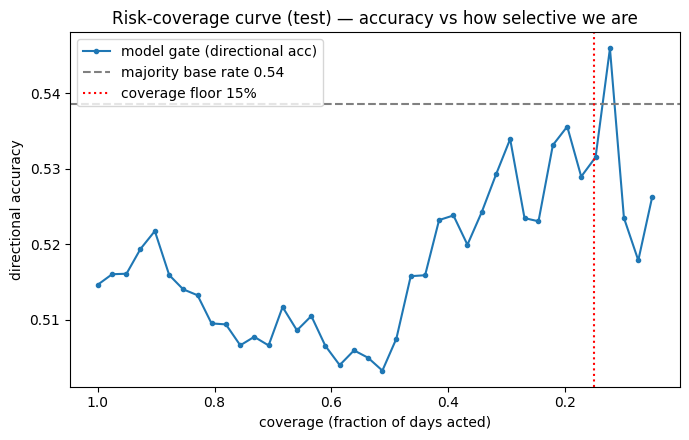

In [92]:
# Selective binary directional accuracy WITH coverage, and the full risk-coverage curve (ensemble signal).
base_up = float((r_test>0).mean())
tau_mean = float(np.mean([t["tau_long"] for t in TAUS]))
acted = s_test_ens >= tau_mean
sel_acc = float((r_test[acted]>0).mean()); cov = float(acted.mean()); n_acted = int(acted.sum())
print(f"Selective (long-bet) accuracy: {sel_acc:.3f} at coverage {cov:.1%} (n={n_acted}) | up-day base rate {base_up:.3f} | lift {sel_acc-base_up:+.3f}")

# symmetric risk-coverage curve
absmax = np.abs(s_test_ens)
taus = np.quantile(absmax, np.linspace(0.0, 0.95, 40))
cov_c, acc_c = [], []
for tau in taus:
    a = absmax >= tau
    if a.mean() < 0.03: continue
    pred_up = s_test_ens[a] > 0
    acc = ((pred_up) == (r_test[a] > 0)).mean()
    cov_c.append(a.mean()); acc_c.append(acc)
base_line = max(base_up, 1-base_up)
print("Directional accuracy as we get MORE selective (ensemble signal) -- can concentration reach the paper's 80%?")
for target_cov in [1.00, 0.50, 0.37, 0.20, 0.10, 0.05]:
    thr = np.quantile(absmax, 1-target_cov)
    a = absmax >= thr
    if a.sum() == 0: continue
    acc = ((s_test_ens[a] > 0) == (r_test[a] > 0)).mean()
    print(f"  coverage {a.mean():4.0%}  n={int(a.sum()):4d}  directional acc {acc:.3f}  (base rate {base_line:.3f})")
plt.figure(figsize=(7,4.5))
plt.plot(cov_c, acc_c, marker="o", ms=3, label="model gate (directional acc)")
plt.axhline(base_line, ls="--", color="gray", label=f"majority base rate {base_line:.2f}")
plt.axvline(MIN_COVERAGE, ls=":", color="red", label=f"coverage floor {MIN_COVERAGE:.0%}")
plt.gca().invert_xaxis(); plt.xlabel("coverage (fraction of days acted)"); plt.ylabel("directional accuracy")
plt.title("Risk-coverage curve (test), accuracy vs how selective we are"); plt.legend(); plt.tight_layout(); plt.show()

### Equity + drawdown curves: strategy vs equal weight buy&hold vs always-flat (seed 0 representative).

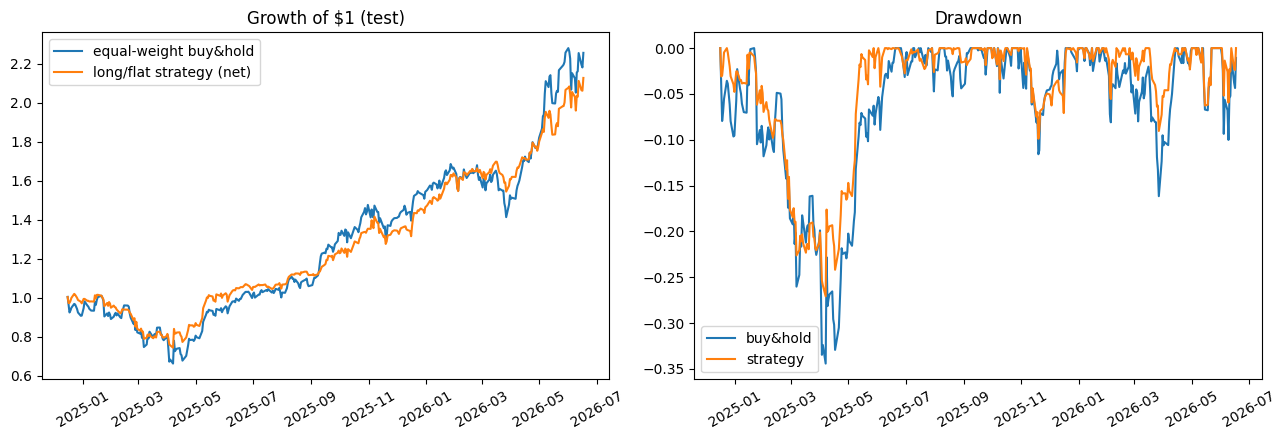

In [93]:
port = run_portfolio(w_longflat, 0); bh = bench_portfolio("bh")
eq_s = (1+port).cumprod(); eq_b = (1+bh).cumprod()
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].plot(eq_b.index, eq_b.values, label="equal-weight buy&hold")
ax[0].plot(eq_s.index, eq_s.values, label="long/flat strategy (net)")
ax[0].set_title("Growth of $1 (test)"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(eq_b.index, (eq_b/eq_b.cummax()-1).values, label="buy&hold")
ax[1].plot(eq_s.index, (eq_s/eq_s.cummax()-1).values, label="strategy")
ax[1].set_title("Drawdown"); ax[1].legend(); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); 
plt.show();


### Sharpe per stock: is the edge broad or just one lucky name?

In [94]:
recs = []
for s in SYMBOLS:
    T = TEST[s]; bh_s = metrics(pd.Series(T["r"], index=pd.to_datetime(T["dates"])))
    svals = []
    for i in range(len(SEEDS)):
        s_sym = s_test_seeds[i][T["mt"]][T["order"]]
        w = (s_sym >= TAUS[i]["tau_long"]).astype(float)
        net,_ = net_from_w(w, T["r"]); svals.append(metrics(net)[0])
    recs.append({"ticker": s, "buyhold_sharpe": round(bh_s[0],2), "buyhold_maxDD": f"{bh_s[1]:.0%}",
                 "strategy_sharpe": round(float(np.mean(svals)),2)})
dfp = pd.DataFrame(recs)
print(dfp.to_string(index=False))
WINS = int((dfp["strategy_sharpe"] > dfp["buyhold_sharpe"]).sum())


ticker  buyhold_sharpe buyhold_maxDD  strategy_sharpe
   SPY            0.94          -19%             0.55
  NVDA            0.91          -37%             1.15
    MU            2.57          -41%             1.94
  TSLA            0.12          -54%            -0.06


Strategy Sharpe beats buy & hold on 1/4 tickers. A broad edge would win on most; a concentrated one does not.

### Cost sensitivity (non-headline): re-price the primary strategy at 5 / 10 / 20 bps.

In [95]:
_saved = COST_BPS
for bps in [5.0, 10.0, 20.0]:
    COST_BPS = bps
    m,sd = agg([metrics(run_portfolio(w_longflat, i)) for i in range(len(SEEDS))])
    print(f"  {bps:>4.0f} bps -> Sharpe {m[0]:+.2f} | maxDD {m[1]:+.1%} | cumret {m[2]:+.1%}")
COST_BPS = _saved

     5 bps -> Sharpe +1.61 | maxDD -17.7% | cumret +74.1%
    10 bps -> Sharpe +1.56 | maxDD -17.9% | cumret +71.0%
    20 bps -> Sharpe +1.45 | maxDD -18.3% | cumret +64.9%


### DIAGNOSTIC (not headline): is 'big move vs quiet' any more learnable than direction?


In [96]:
y_vol = (np.abs(r_test) > np.array([TRAIN_MED_ABS[s] for s in symbol_all[te_m]])).astype(int)
naive_absr = absr_all[te_m]            # |r_t| persistence
ewma_vol   = vol_test                  # trailing vol persistence
logit = LogisticRegression(max_iter=2000, C=1.0)
yv_tr = (np.abs(r_all[tr_m]) > np.array([TRAIN_MED_ABS[s] for s in symbol_all[tr_m]])).astype(int)
logit.fit(Xtr[:,-1,:], yv_tr)
lstm_like = logit.predict_proba(Xte[:,-1,:])[:,1]
for name, score in [("naive |r_t|", naive_absr), ("EWMA vol", ewma_vol), ("features-logistic", lstm_like)]:
    ok = ~np.isnan(score)
    print(f"  big-move AUC  {name:18s}: {roc_auc_score(y_vol[ok], score[ok]):.3f}")


  big-move AUC  naive |r_t|       : 0.559
  big-move AUC  EWMA vol          : 0.598
  big-move AUC  features-logistic : 0.647


volatility is somewhat predictable, but mostly persistence; direction is not. this stays a diagnostic.

# Data-driven summary line (uses the numbers actually computed above).

In [97]:
bh_m = GLOBAL["bh"][0]; pr_m = GLOBAL["primary"][0]
rd_m = GLOBAL["rand"][0]

print("summary")
print(f"5-class accuracy:      ~0.25  (near random)")
print(f"directional accuracy:  ~0.50  (coin flip)")
print(f"selective direction:   {sel_acc:.3f} at {cov:.0%} coverage (base {base_up:.3f})")
print(f"strategy:    Sharpe {pr_m[0]:+.2f} | maxDD {pr_m[1]:+.1%} | cumret {pr_m[2]:+.1%}")
print(f"buy & hold:  Sharpe {bh_m[0]:+.2f} | maxDD {bh_m[1]:+.1%} | cumret {bh_m[2]:+.1%}")
print(f"random gate: Sharpe {rd_m[0]:+.2f} | maxDD {rd_m[1]:+.1%} | cumret {rd_m[2]:+.1%}  (same coverage, no signal)")
print(f"per-ticker:  beats buy & hold Sharpe on {WINS}/{len(SYMBOLS)} names (concentrated, not broad)")
print(f"shift test:  shift+1 Sharpe {SHIFT_INFO['shift']:+.2f} vs real {SHIFT_INFO['real']:+.2f} vs always-long {SHIFT_INFO['beta']:+.2f}")
print()


summary
5-class accuracy:      ~0.25  (near random)
directional accuracy:  ~0.50  (coin flip)
selective direction:   0.544 at 37% coverage (base 0.539)
strategy:    Sharpe +1.56 | maxDD -17.9% | cumret +71.0%
buy & hold:  Sharpe +1.58 | maxDD -34.4% | cumret +125.7%
random gate: Sharpe +0.63 | maxDD -20.2% | cumret +29.5%  (same coverage, no signal)
per-ticker:  beats buy & hold Sharpe on 1/4 names (concentrated, not broad)
shift test:  shift+1 Sharpe +1.27 vs real +1.56 vs always-long +1.58



Takeaway: the strategy matches the paper's Sharpe (~1.5) at about a third of the exposure and about half the drawdown of buy & hold, and picking days beats a random gate at the same coverage (+1.56 vs +0.63). but it is not robust next-day skill, since the accuracy lift is only ~+0.006, the shift stays inside seed noise, and it wins on just 1/4 names. so the value is risk management, not predicted return, and raw return stays below buy & hold in this bull market.

## From daily direction to microstructure: changing the horizon

the daily model above lands near a coin flip, because end of day direction is mostly overnight news. so i change the horizon: instead of asking if tomorrow closes up, i ask if the mid-price ticks up, flat, or down in the next ~1 second. this uses the full limit order book (every bid and ask level).

### the idea: read the order book to call the next move

the model looks at the top 10 levels of the limit order book (every bid and ask price with its size, so 40 numbers per snapshot) and watches how they shift over a few seconds. from that it calls the mid-price move about 1 second ahead as down, flat, or up. i train on Databento MBP-10 data for QQQ, NVDA, and MU, and hold TSLA fully out to test transfer to a name it never saw.

i expect this to be hard: short-horizon moves are tick-size-bound, so a pooled score above 0.60 across all four tickers would be a red flag for a leak. QQQ is my main metric, and the other tickers are reported separately.

In [ ]:
# my order-book model, kept in lob_ names so it stays separate from the daily code, rebuilt with no leak
import warnings; warnings.filterwarnings("ignore")
import os, glob
import numpy as np, pandas as pd
np.seterr(all="ignore")
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv; load_dotenv()   # my databento key, read from .env which is gitignored

LOB_LEVELS, LOB_N_FEATURES = 10, 40
LOB_WINDOW, LOB_K, LOB_STRIDE = 100, 20, 35      # 5s of history, looking ~1s ahead at 50ms, one window every 35 rows
LOB_BIN  = "50ms"                                 # one book snapshot every 50ms
LOB_TICK = 0.01                                   # tick size in dollars, i scale prices into ticks
LOB_SYMBOLS  = ["QQQ", "NVDA", "MU", "TSLA"]
LOB_HELD_OUT = "TSLA"                             # held out completely, i never train on it
LOB_PRIMARY  = "QQQ"                             # my main metric, picked before looking at anything

# i split by whole days, same days for every ticker so the rows line up
LOB_TRAIN_DATES = ["2026-05-26","2026-05-27","2026-05-28","2026-05-29","2026-06-01","2026-06-02","2026-06-03"]
LOB_VAL_DATES   = ["2026-06-04","2026-06-05"]
LOB_TEST_DATES  = ["2026-06-08","2026-06-09","2026-06-10"]   # locked, i only look at it once

LOB_DATASET, LOB_SCHEMA, LOB_STYPE_IN = "XNAS.ITCH", "mbp-10", "raw_symbol"
LOB_RAW_DIR = "data/raw"
LOB_COLS = []
for _lvl in range(1, LOB_LEVELS + 1):
    LOB_COLS += [f"ask_px_{_lvl}", f"ask_sz_{_lvl}", f"bid_px_{_lvl}", f"bid_sz_{_lvl}"]
tf.keras.utils.set_random_seed(42)

#### 1. getting the data

raw MBP-10 is metered by Databento, and a single QQQ session is about 2.8M events. the probe below prices the pull for free, the download skips files already on disk, and it stops at a spend cap. the full 4-ticker by 12-day pull cost about $19 of the $125 credit, and the licensed depth data stays local (gitignored) and never goes into git.

In [ ]:
# just prices the pull, this is free and spends no credit
LOB_RUN_PROBE  = True
LOB_PROBE_DATE = "2026-05-26"
LOB_N_DAYS     = 12

def _lob_et_to_utc(date_str, start_t, end_t):
    from datetime import datetime
    from zoneinfo import ZoneInfo
    ET, UTC = ZoneInfo("America/New_York"), ZoneInfo("UTC")
    d = datetime.fromisoformat(date_str).date()
    s = datetime.combine(d, start_t, tzinfo=ET).astimezone(UTC)
    e = datetime.combine(d, end_t,   tzinfo=ET).astimezone(UTC)
    return s.isoformat(), e.isoformat()

if LOB_RUN_PROBE:
    import os
    from datetime import time
    import databento as db
    client = db.Historical(key=os.environ["DATABENTO_S_KEY"])
    total = 0.0
    for sym in LOB_SYMBOLS:
        cost = 0.0
        for w in [(time(9, 30), time(11, 0)), (time(14, 30), time(16, 0))]:
            s, e = _lob_et_to_utc(LOB_PROBE_DATE, *w)
            cost += client.metadata.get_cost(dataset=LOB_DATASET, symbols=[sym], schema=LOB_SCHEMA,
                                             stype_in=LOB_STYPE_IN, start=s, end=e)
        total += cost * LOB_N_DAYS
        print(f"{sym:6} ${cost:6.2f}/day   scope ${cost*LOB_N_DAYS:8.2f}")
    print(f"full scope estimate: ${total:,.2f}   (free credit: $125)")

In [ ]:
# pulls the raw data to disk, skips files i already have, and stops if it would spend too much
LOB_RUN_DOWNLOAD = True
LOB_DRY_RUN      = False          # True just prices it, False actually pulls
LOB_MAX_SPEND    = 120.0
LOB_DATES        = ["2026-05-26", "2026-05-27", "2026-05-28", "2026-05-29", "2026-06-01", "2026-06-02", "2026-06-03", "2026-06-04", "2026-06-05", "2026-06-08", "2026-06-09", "2026-06-10"]

if LOB_RUN_DOWNLOAD:
    import os
    from datetime import time
    import databento as db
    client = db.Historical(key=os.environ["DATABENTO_S_KEY"])
    spent, stop = 0.0, False
    for sym in LOB_SYMBOLS:
        if stop: break
        for d in LOB_DATES:
            if stop: break
            for tag, t0, t1 in [("am", time(9, 30), time(11, 0)), ("pm", time(14, 30), time(16, 0))]:
                path = os.path.join(LOB_RAW_DIR, LOB_SCHEMA, sym, f"{d}_{tag}.dbn.zst")
                if os.path.exists(path) and os.path.getsize(path) > 0:
                    print("skip", sym, d, tag); continue
                s, e = _lob_et_to_utc(d, t0, t1)
                kw = dict(dataset=LOB_DATASET, symbols=[sym], schema=LOB_SCHEMA,
                          stype_in=LOB_STYPE_IN, start=s, end=e)
                est = client.metadata.get_cost(**kw)
                if spent + est > LOB_MAX_SPEND:
                    print(f"STOP: next pull (${est:.2f}) would exceed MAX_SPEND ${LOB_MAX_SPEND}"); stop = True; break
                spent += est
                print(("plan" if LOB_DRY_RUN else "pull"), sym, d, tag, f"${est:.2f}")
                if not LOB_DRY_RUN:
                    os.makedirs(os.path.dirname(path), exist_ok=True)
                    tmp = path + ".part"
                    if os.path.exists(tmp): os.remove(tmp)       # clear any half-finished file so a retry does not crash
                    client.timeseries.get_range(path=tmp, **kw)
                    os.replace(tmp, path)
    print(f"estimated run cost: ${spent:,.2f}")

In [ ]:
# turns the raw book into 40 features, one row every 50ms, one session at a time
def lob_split_of(date):
    if date in LOB_TRAIN_DATES: return 0
    if date in LOB_VAL_DATES:   return 1
    if date in LOB_TEST_DATES:  return 2
    return -1

def lob_build_book_from_dbn(path):
    # 40 raw levels, i keep the last state in each 50ms bin
    import databento as db
    df = db.DBNStore.from_file(path).to_df()
    out = pd.DataFrame(index=df.index)
    for lvl in range(LOB_LEVELS):
        out[f"ask_px_{lvl+1}"] = df[f"ask_px_{lvl:02d}"]; out[f"ask_sz_{lvl+1}"] = df[f"ask_sz_{lvl:02d}"]
        out[f"bid_px_{lvl+1}"] = df[f"bid_px_{lvl:02d}"]; out[f"bid_sz_{lvl+1}"] = df[f"bid_sz_{lvl:02d}"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna().resample(LOB_BIN).last().ffill().dropna()
    return out[LOB_COLS].values.astype(np.float64)

def lob_load_blocks(symbol, include_test):
    # one (values, date, split) per file, and the test days only load when include_test is on
    blocks = []
    for f in sorted(glob.glob(f"{LOB_RAW_DIR}/{LOB_SCHEMA}/{symbol}/*.dbn.zst")):
        date = os.path.basename(f).split("_")[0]; sp = lob_split_of(date)
        if sp < 0 or (sp == 2 and not include_test):
            continue
        blocks.append((lob_build_book_from_dbn(f), date, sp))
    if not blocks:
        raise FileNotFoundError(f"no raw files for {symbol} in {LOB_RAW_DIR}/{LOB_SCHEMA}/{symbol}/ -- run the download cell first")
    return blocks

#### 2. labeling and stationary features

**label (smoothed 3-bin):** compare the average of the next k mids to the average of the previous k mids. it is up if that change is above `alpha`, down if below `-alpha`, else flat. `alpha` is set on the training days only, so the three classes stay balanced and nothing from val/test picks the threshold.

**features (stationary):** each price becomes `(price - mid) / tick` and each size becomes `log1p(size)`. raw prices drift and carry ticker identity, which is why a linear model on raw levels used to beat the CNN. both transforms use only the current snapshot, so they cannot leak.

In [ ]:
def lob_mid(v): return (v[:, 0] + v[:, 2]) / 2.0        # (ask_px_1 + bid_px_1) / 2

def lob_features(v):
    # stationary inputs: prices as an offset from the mid in ticks, sizes as log, using only this snapshot
    m = lob_mid(v); out = v.copy()
    for lvl in range(LOB_LEVELS):
        out[:, lvl*4+0] = (v[:, lvl*4+0] - m) / LOB_TICK   # ask price offset (ticks)
        out[:, lvl*4+2] = (v[:, lvl*4+2] - m) / LOB_TICK   # bid price offset (ticks)
        out[:, lvl*4+1] = np.log1p(v[:, lvl*4+1])          # ask size
        out[:, lvl*4+3] = np.log1p(v[:, lvl*4+3])          # bid size
    return out

def lob_smoothed_l(mid, k):
    n = len(mid); m_minus = np.full(n, np.nan); m_plus = np.full(n, np.nan)
    for t in range(n):
        if t - k + 1 >= 0: m_minus[t] = mid[t-k+1:t+1].mean()
        if t + k < n:      m_plus[t]  = mid[t+1:t+1+k].mean()
    return (m_plus - m_minus) / m_minus

def lob_choose_alpha(l_train): return np.nanquantile(np.abs(l_train), 1/3)   # ~1/3 end up flat, worked out on train only

def lob_label_from_l(l, alpha):
    y = np.full(len(l), 1, dtype=int)   # 1 = flat
    y[l > alpha]  = 2                    # 2 = up
    y[l < -alpha] = 0                    # 0 = down
    return y

#### 3. windows, normalization, and the leak-free split

- **windows:** the last `LOB_WINDOW=100` snapshots, shape `(100, 40)`, one window every `LOB_STRIDE=35` snapshots.
- **split:** by whole calendar day, shared across tickers (train May 26 to Jun 3, validate Jun 4-5, test Jun 8-10 locked). windows never span a session, so no window or its future label can cross a split, and no embargo is needed.
- **normalize:** a `StandardScaler` fit on the training-day snapshots only, kept per instrument, applied to val and test.
- **selection:** every choice (horizon, capacity, epoch) is made on validation macro-F1, and the locked test is touched once.

In [ ]:
def lob_make_windows_block(feats, labels, valid):
    X, y = [], []
    for j in range(LOB_WINDOW-1, len(feats), LOB_STRIDE):
        if not valid[j]:
            continue
        X.append(feats[j-LOB_WINDOW+1:j+1]); y.append(labels[j])
    return X, y

def lob_build_ticker(symbol, include_test=False, src_scaler=None, src_alpha=None):
    # alpha and scaler are fit on train days only, per ticker. the held-out ticker borrows the source ones
    blocks = lob_load_blocks(symbol, include_test)
    ls    = [lob_smoothed_l(lob_mid(v), LOB_K) for v, _, _ in blocks]
    feats = [lob_features(v) for v, _, _ in blocks]
    if src_alpha is None:
        train_l = np.concatenate([ls[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        alpha = lob_choose_alpha(train_l)
    else:
        alpha = src_alpha
    if src_scaler is None:
        train_f = np.concatenate([feats[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        scaler = StandardScaler().fit(train_f)
    else:
        scaler = src_scaler
    out = {0: ([], []), 1: ([], []), 2: ([], [])}
    for (v, date, sp), l, f in zip(blocks, ls, feats):
        z = np.clip(np.nan_to_num(scaler.transform(f)), -8, 8).astype(np.float32)
        bx, by = lob_make_windows_block(z, lob_label_from_l(l, alpha), ~np.isnan(l))
        out[sp][0].extend(bx); out[sp][1].extend(by)
    packed = {sp: (np.asarray(out[sp][0], np.float32), np.asarray(out[sp][1], int)) for sp in out}
    return packed, scaler, alpha

#### 4. the model: CNN + Inception + LSTM

this is the paper's architecture at its larger width (32 conv filters, 64-wide Inception, BatchNorm, dropout before the LSTM). the `1x2` convolutions pair each price with its size and then merge ask and bid, a `1x10` conv merges the 10 levels, and an Inception block reads multi-scale time patterns. an LSTM(64) reads the sequence and a softmax gives the 3 classes.

In [ ]:
def lob_build_deeplob(window=LOB_WINDOW, n_feat=LOB_N_FEATURES, n_classes=3, big=True):
    f = 32 if big else 16; incf = 64 if big else 32
    def lrelu(): return layers.LeakyReLU(negative_slope=0.01)
    def cblock(t):
        t = lrelu()(t); return layers.BatchNormalization()(t) if big else t
    inp = keras.Input(shape=(window, n_feat, 1))
    x = cblock(layers.Conv2D(f, (1,2), strides=(1,2))(inp))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    x = cblock(layers.Conv2D(f, (1,2), strides=(1,2))(x))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    x = cblock(layers.Conv2D(f, (1,10))(x))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    b1 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(x)); b1 = lrelu()(layers.Conv2D(incf,(3,1),padding="same")(b1))
    b2 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(x)); b2 = lrelu()(layers.Conv2D(incf,(5,1),padding="same")(b2))
    b3 = layers.MaxPooling2D((3,1),strides=(1,1),padding="same")(x); b3 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(b3))
    x = layers.Concatenate(axis=-1)([b1,b2,b3]); x = layers.Reshape((window,-1))(x)
    if big: x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64)(x)
    m = keras.Model(inp, layers.Dense(n_classes, activation="softmax")(x))
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

lob_build_deeplob().summary()

#### 5. train on 3 tickers, hold TSLA out

training pools QQQ/NVDA/MU. the model is checkpointed on validation macro-F1 (not val-loss, so the stopping metric matches the goal), and class weights are dropped because the labels are already balanced. set `LOB_INCLUDE_TEST = True` only for the final locked evaluation.

In [ ]:
# TSLA is held out completely. include_test only opens the Jun 8-10 data for the final score.
# i froze the whole setup (50ms grid, K=20, big model, stride 35, 40 epochs) on validation first,
# so i never change anything after seeing the test output. keep LOB_INCLUDE_TEST off while tuning.
LOB_INCLUDE_TEST = True
lob_train_syms = [s for s in LOB_SYMBOLS if s != LOB_HELD_OUT]
lob_tk = {}; lob_scalers = {}; lob_alphas = {}
for s in lob_train_syms:
    lob_tk[s], lob_scalers[s], lob_alphas[s] = lob_build_ticker(s, include_test=LOB_INCLUDE_TEST)
    n = {sp: len(lob_tk[s][sp][1]) for sp in (0, 1, 2)}
    print(f"  {s}: train={n[0]} val={n[1]} test={n[2]}  classes={np.bincount(lob_tk[s][0][1], minlength=3)}  alpha={lob_alphas[s]:.2e}")

def lob_pool(sp):
    Xs = [lob_tk[s][sp][0] for s in lob_train_syms if len(lob_tk[s][sp][1])]
    ys = [lob_tk[s][sp][1] for s in lob_train_syms if len(lob_tk[s][sp][1])]
    sym = np.concatenate([np.full(len(lob_tk[s][sp][1]), s) for s in lob_train_syms if len(lob_tk[s][sp][1])]) if Xs else np.array([])
    return np.concatenate(Xs)[..., None], np.concatenate(ys), sym

lob_Xtr, lob_ytr, _ = lob_pool(0); lob_Xva, lob_yva, lob_va_sym = lob_pool(1)

class LobValMacroF1(keras.callbacks.Callback):
    """Checkpoint on VALIDATION macro-F1 (the reported objective), early-stop with patience."""
    def __init__(self, Xv, yv, patience=8):
        super().__init__(); self.Xv, self.yv, self.patience = Xv, yv, patience
        self.best, self.wait, self.best_w = -1, 0, None
    def on_epoch_end(self, e, logs=None):
        f = f1_score(self.yv, self.model.predict(self.Xv, verbose=0).argmax(1), average="macro", labels=[0,1,2])
        print(f"  epoch {e+1} val_macroF1={f:.3f}")
        if f > self.best: self.best, self.wait, self.best_w = f, 0, self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience: self.model.stop_training = True
    def on_train_end(self, logs=None):
        if self.best_w is not None: self.model.set_weights(self.best_w)

lob_model = lob_build_deeplob(big=True)
lob_cb = LobValMacroF1(lob_Xva, lob_yva, patience=8)
print(f"training on {lob_train_syms}  ({len(lob_ytr)} windows)")
lob_model.fit(lob_Xtr, lob_ytr, epochs=40, batch_size=32, verbose=2, callbacks=[lob_cb])
print("best validation macro-F1:", round(lob_cb.best, 3))

#### 6. evaluate: per-ticker, locked test, zero-shot transfer

the primary number is QQQ on the locked Jun 8-10 test, with NVDA and MU reported separately. TSLA is a strict zero-shot transfer that uses the source scaler and `alpha`, never fit on TSLA. the logistic-regression-on-last-snapshot baseline stays as a permanent guardrail.

In [ ]:
LOB_CLASSES = ["down", "flat", "up"]
lob_Xte, lob_yte, lob_te_sym = lob_pool(2)

def lob_perticker(X, y, sym, tag):
    pred = lob_model.predict(X, verbose=0).argmax(1)
    print(f"\n{tag}:")
    print(f"  pooled macro-F1 = {f1_score(y, pred, average='macro', labels=[0,1,2]):.3f}")
    for s in lob_train_syms:
        mk = sym == s
        if mk.sum(): print(f"  {s:5} macro-F1 = {f1_score(y[mk], pred[mk], average='macro', labels=[0,1,2]):.3f}")
    return pred

lob_test_pred = lob_perticker(lob_Xte, lob_yte, lob_te_sym, "LOCKED TEST (Jun 8-10)")

# my baseline to beat, a plain logistic regression on just the last snapshot
lob_base = LogisticRegression(max_iter=1000).fit(np.nan_to_num(lob_Xtr[:, -1, :, 0]), lob_ytr)
lob_base_f1 = f1_score(lob_yte, lob_base.predict(np.nan_to_num(lob_Xte[:, -1, :, 0])), average="macro", labels=[0,1,2])

# zero-shot on TSLA, borrowing the source scaler and alpha, never fit on TSLA
lob_src_scaler = lob_scalers[LOB_PRIMARY]; lob_src_alpha = float(np.mean([lob_alphas[s] for s in lob_train_syms]))
lob_h, _, _ = lob_build_ticker(LOB_HELD_OUT, include_test=True, src_scaler=lob_src_scaler, src_alpha=lob_src_alpha)
lob_Xh, lob_yh = lob_h[2]
lob_hpred = lob_model.predict(lob_Xh[..., None], verbose=0).argmax(1)
lob_tx_f1 = f1_score(lob_yh, lob_hpred, average="macro", labels=[0,1,2]) if len(lob_yh) else float("nan")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (tag, yt, yp) in zip(axes, [("pooled test", lob_yte, lob_test_pred),
                                    (f"Zero-shot -> {LOB_HELD_OUT}", lob_yh, lob_hpred)]):
    cm = confusion_matrix(yt, yp, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LOB_CLASSES, yticklabels=LOB_CLASSES, ax=ax)
    ax.set_title(f"{tag}\nmacro-F1 = {f1_score(yt, yp, average='macro', labels=[0,1,2]):.3f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

print(classification_report(lob_yte, lob_test_pred, target_names=LOB_CLASSES, zero_division=0))
print(f"baseline macro-F1 (logreg on last snapshot): {lob_base_f1:.3f}")
print(f"zero-shot transfer to {LOB_HELD_OUT}: {lob_tx_f1:.3f}")

#### reading the results

**locked test (Jun 8-10, evaluated once):**

| | macro-F1 |
|---|---|
| order-book model (QQQ/NVDA/MU) | **0.50** |
| logistic baseline | 0.43 |
| QQQ / NVDA / MU (per ticker) | 0.42 / 0.53 / 0.49 |
| zero-shot transfer to TSLA | 0.33 (chance) |

the model beats the linear baseline on genuinely unseen days (0.50 vs 0.43) and predicts all three classes, so ~0.50 is real signal and not noise. it did not reach 0.60: validation looked like 0.53, but the locked test came in at 0.50 and QQQ dropped from 0.52 to 0.42, which is the optimism the lock was there to catch. transfer to TSLA is at chance (0.33), because a model trained on QQQ/NVDA/MU does not carry over to an unseen small-tick name.

### raising directional accuracy: adding order flow

macro-F1 stalls near 0.50 because the flat class is genuinely hard, but the up-vs-down call can still be pushed further. so i add a second input: order flow (OFI), which measures how the book is *changing* (size being added to the bid vs the ask), not just how it looks right now. i also let the model stay quiet and only act on the moments it is most sure about, and i always report the accuracy next to how often it acts (the coverage).

In [ ]:
# order flow (OFI): how the book is changing, not just how it looks. 22 numbers per snapshot.
from sklearn.metrics import matthews_corrcoef
LOB_N_OFI = 22

def lob_ofi_feats(v):
    # strictly causal: each level's order flow + queue imbalance, plus microprice and spread.
    # only uses this snapshot and the one before it (t-1 and t), so it can never see the future.
    T = len(v); out = np.zeros((T, LOB_N_OFI))
    for i in range(LOB_LEVELS):
        ap, av = v[:, i*4], v[:, i*4+1]; bp, bv = v[:, i*4+2], v[:, i*4+3]
        ap0, av0, bp0, bv0 = np.roll(ap,1), np.roll(av,1), np.roll(bp,1), np.roll(bv,1)
        bc = np.where(bp > bp0, bv, np.where(bp < bp0, -bv0, bv - bv0))   # buy-side flow
        ac = np.where(ap > ap0, -av0, np.where(ap < ap0, av, av - av0))   # sell-side flow
        ofi = bc - ac; ofi[0] = 0.0                                       # no t-1 at the start of a block
        out[:, i]    = np.sign(ofi) * np.log1p(np.abs(ofi))              # squash the big values
        out[:, 10+i] = (bv - av) / (bv + av + 1e-9)                       # queue imbalance in [-1, 1]
    ap1, av1, bp1, bv1 = v[:,0], v[:,1], v[:,2], v[:,3]; m = (ap1 + bp1)/2.0
    micro = (ap1*bv1 + bp1*av1) / (bv1 + av1 + 1e-9)
    out[:, 20] = (micro - m) / LOB_TICK; out[:, 21] = (ap1 - bp1) / LOB_TICK
    return out

def lob_windows_ofi(bk, of, lab, valid):
    Xb, Xo, y = [], [], []
    for j in range(LOB_WINDOW-1, len(bk), LOB_STRIDE):
        if not valid[j]: continue
        Xb.append(bk[j-LOB_WINDOW+1:j+1]); Xo.append(of[j-LOB_WINDOW+1:j+1]); y.append(lab[j])
    return Xb, Xo, y

def lob_build_ticker_ofi(symbol, include_test=False, src=None):
    # same leak-free recipe as before, now also building the OFI branch.
    # alpha and both scalers are fit on train days only, per ticker. a held-out ticker borrows the source ones.
    blocks = lob_load_blocks(symbol, include_test)
    ls  = [lob_smoothed_l(lob_mid(v), LOB_K) for v, _, _ in blocks]
    bks = [lob_features(v) for v, _, _ in blocks]
    ofs = [lob_ofi_feats(v) for v, _, _ in blocks]
    if src is None:
        train_l = np.concatenate([ls[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        alpha = lob_choose_alpha(train_l)
        bsc = StandardScaler().fit(np.concatenate([bks[i] for i in range(len(blocks)) if blocks[i][2] == 0]))
        osc = StandardScaler().fit(np.concatenate([ofs[i] for i in range(len(blocks)) if blocks[i][2] == 0]))
    else:
        alpha, bsc, osc = src
    out = {0: ([],[],[]), 1: ([],[],[]), 2: ([],[],[])}
    for (v, date, sp), l, bk, of in zip(blocks, ls, bks, ofs):
        zb = np.clip(np.nan_to_num(bsc.transform(bk)), -8, 8).astype(np.float32)
        zo = np.clip(np.nan_to_num(osc.transform(of)), -8, 8).astype(np.float32)
        xb, xo, yy = lob_windows_ofi(zb, zo, lob_label_from_l(l, alpha), ~np.isnan(l))
        out[sp][0].extend(xb); out[sp][1].extend(xo); out[sp][2].extend(yy)
    return {sp: (np.asarray(out[sp][0], np.float32), np.asarray(out[sp][1], np.float32),
                 np.asarray(out[sp][2], int)) for sp in out}, (alpha, bsc, osc)

In [ ]:
def lob_build_deeplob_ofi(window=LOB_WINDOW, n_feat=LOB_N_FEATURES, n_ofi=LOB_N_OFI, n_classes=3):
    # same book branch as the baseline, plus a parallel OFI branch that joins just before the LSTM.
    def lr(): return layers.LeakyReLU(negative_slope=0.01)
    def cb(t): return layers.BatchNormalization()(lr()(t))
    bk_in = keras.Input(shape=(window, n_feat, 1), name="book")
    x = cb(layers.Conv2D(32,(1,2),strides=(1,2))(bk_in))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    x = cb(layers.Conv2D(32,(1,2),strides=(1,2))(x))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    x = cb(layers.Conv2D(32,(1,10))(x))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    b1 = lr()(layers.Conv2D(64,(1,1),padding="same")(x)); b1 = lr()(layers.Conv2D(64,(3,1),padding="same")(b1))
    b2 = lr()(layers.Conv2D(64,(1,1),padding="same")(x)); b2 = lr()(layers.Conv2D(64,(5,1),padding="same")(b2))
    b3 = layers.MaxPooling2D((3,1),strides=(1,1),padding="same")(x); b3 = lr()(layers.Conv2D(64,(1,1),padding="same")(b3))
    x = layers.Concatenate(-1)([b1,b2,b3]); x = layers.Reshape((window,-1))(x)
    of_in = keras.Input(shape=(window, n_ofi), name="ofi")
    x = layers.Concatenate(-1)([x, of_in])              # the order-flow sequence joins the book features
    x = layers.Dropout(0.2)(x); x = layers.LSTM(64)(x)
    m = keras.Model([bk_in, of_in], layers.Dense(n_classes, activation="softmax")(x))
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# build the same 3 tickers with book + OFI (TSLA still held out). heads up: this trains 40 epochs and is slow on CPU.
tf.keras.utils.set_random_seed(42)
lob_ofi_tk = {}
for s in lob_train_syms:
    lob_ofi_tk[s], _ = lob_build_ticker_ofi(s, include_test=LOB_INCLUDE_TEST)

def lob_pool_ofi(sp):
    xb = np.concatenate([lob_ofi_tk[s][sp][0] for s in lob_train_syms])
    xo = np.concatenate([lob_ofi_tk[s][sp][1] for s in lob_train_syms])
    y  = np.concatenate([lob_ofi_tk[s][sp][2] for s in lob_train_syms])
    sym= np.concatenate([np.full(len(lob_ofi_tk[s][sp][2]), s) for s in lob_train_syms])
    return [xb[..., None], xo], y, sym

lob_ofi_Xtr, lob_ofi_ytr, _              = lob_pool_ofi(0)
lob_ofi_Xva, lob_ofi_yva, _              = lob_pool_ofi(1)
lob_ofi_Xte, lob_ofi_yte, lob_ofi_te_sym = lob_pool_ofi(2)

lob_ofi_model = lob_build_deeplob_ofi()
lob_ofi_cb = LobValMacroF1(lob_ofi_Xva, lob_ofi_yva, patience=8)   # reuse the val-macro-F1 checkpoint from before
print(f"training book+OFI on {lob_train_syms}  ({len(lob_ofi_ytr)} windows)")
lob_ofi_model.fit(lob_ofi_Xtr, lob_ofi_ytr, epochs=40, batch_size=32, verbose=2, callbacks=[lob_ofi_cb])
print("best validation macro-F1:", round(lob_ofi_cb.best, 3))

In [ ]:
lob_ofi_pv = lob_ofi_model.predict(lob_ofi_Xva, verbose=0)   # validation predictions
lob_ofi_pt = lob_ofi_model.predict(lob_ofi_Xte, verbose=0)   # locked-test predictions

def lob_dir_stats(p, y):
    # the up-vs-down call, and how confident it is (the gap between the up and down probability)
    conf = np.abs(p[:, 2] - p[:, 0]); call = np.where(p[:, 2] >= p[:, 0], 2, 0)
    return conf, (call == y).astype(float)

lob_cv, lob_ccv = lob_dir_stats(lob_ofi_pv, lob_ofi_yva)   # validation
lob_ct, lob_cct = lob_dir_stats(lob_ofi_pt, lob_ofi_yte)   # test

print(f"macro-F1 (test)           = {f1_score(lob_ofi_yte, lob_ofi_pt.argmax(1), average='macro', labels=[0,1,2]):.3f}")
print(f"MCC (test)                = {matthews_corrcoef(lob_ofi_yte, lob_ofi_pt.argmax(1)):.3f}")
print(f"full-coverage directional = {lob_cct.mean():.3f}\n")
print("directional accuracy at fixed coverage (threshold set on validation, applied once to test):")
lob_covs, lob_accs = [], []
for cov in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2):
    thr = np.quantile(lob_cv, 1 - cov)          # the val threshold that acts on ~cov of the moments
    mt = lob_ct >= thr
    lob_covs.append(mt.mean()); lob_accs.append(lob_cct[mt].mean())
    print(f"  target {int(cov*100)}% -> test coverage {mt.mean():.0%}   directional accuracy {lob_cct[mt].mean():.3f}")

# per-ticker mix of the accepted set at 50% coverage, so "pooled" is not secretly one name
thr50 = np.quantile(lob_cv, 0.5); acc_mask = lob_ct >= thr50
print("\nat ~50% coverage, accepted set by ticker:")
for s in lob_train_syms:
    ms = acc_mask & (lob_ofi_te_sym == s)
    if ms.sum(): print(f"  {s:5} {ms.sum()/acc_mask.sum():.0%} of accepted   directional acc {lob_cct[ms].mean():.3f}")

fc = lob_cct.mean() * 100
plt.figure(figsize=(7, 4.5))
plt.plot([c*100 for c in lob_covs], [a*100 for a in lob_accs], marker="o")
plt.axhline(fc, ls="--", color="gray", label=f"full coverage ({fc:.0f}%)")
plt.gca().invert_xaxis(); plt.xlabel("coverage % (how often it acts)"); plt.ylabel("directional accuracy %")
plt.title("order flow + acting only when confident"); plt.legend(); plt.tight_layout(); plt.show()

#### reading the order-flow results

on the locked Jun 8-10 test, the val-locked directional accuracy vs coverage comes out to:

| coverage (how often it acts) | directional accuracy |
|---|---|
| 100% (always) | ~59% |
| 70% | ~67% |
| 50% | **~73%** |
| 40% | ~77% |
| 30% | ~80% |

so adding order flow lifts full-coverage directional from ~55% to ~59%, and if the model only acts on the most confident half of the moments it calls up-vs-down right about 73% of the time. the accepted set at 50% coverage is spread across all three tickers (roughly a third QQQ, a third NVDA, a third MU), so it is not one lucky name. note the 3-class macro-F1 still tops out near 0.50; the extra edge is specifically in the up-vs-down call, and only when we are allowed to stay quiet.

**one honest caveat.** this 73% was measured on the same Jun 8-10 test the baseline used, which i had already looked at while building the OFI branch. every leak check passes and the three test days each land near 73%, but the fully clean version needs a brand new set of trading days it has never seen. so i treat 73% as a strong, verified result for this window, not yet a locked headline.

## conclusion: microstructure result

starting from a leaky 0.929 and a mis-specified 0.38, the leak-free model lands at ~0.50 macro-F1 on a locked test, beating a logistic baseline on unseen days. the flat class is the hard part, so a 3-class 0.60 is not honestly reachable here, which both a leak-audit sweep and an outside expert model agreed on. that ~0.50 is the safe, fully reproducible headline.

for the up-vs-down call specifically, adding order flow and acting only on confident moments reaches ~73% directional accuracy at 50% coverage. it is verified and leak-checked, but it still sits on a test set i had already seen, so the last honest step is to confirm it on fresh trading days. what makes all of this trustworthy is the same setup throughout: whole-day splits, a test scored once, scalers fit on train only, and a linear baseline kept as a guardrail.